# Minicurso 2: Aprendizado Federado Veicular: da Teoria a Prática

Este notebook implementa o código utilizado na atividade prática do minicurso do SBRC 2026.

## Bibliotecas e módulos necessários para a execução da atividade prática do minicurso

In [1]:
%cd ..

/home/gta/airam/MinicursoAprendizadoFederadoVeicularSBRC2026


/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import flwr as fl
import torch
import os

from flwr.common import ndarrays_to_parameters
from collections import OrderedDict
from IPython.display import Image

from utils.data.split_data import generate_datasets
from utils.visualization.distribution import distribution_plot
from architectures.torch.implementation import build_model
from utils.torch.load_federated_data import load_data_client
from utils.torch.utils import create_logger_server
from utils.utils import load_config
from architectures.torch.implementation import get_weights

from architectures.torch.implementation import build_model
from architectures.torch.implementation import (
    train, 
    evaluate,
)

/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyl

## Carregar os parâmetros presentes no arquivo de configurações do sistema

In [3]:
cfg = load_config("configs/config.yaml")

## 1 - Definição do ambiente federado

In [4]:
dataset_name=cfg['simulation']['data']['name']
alpha=cfg['simulation']['data']['alpha']
n_clients=cfg['simulation']['cars']
speeds=cfg['simulation']['speed']['index']

## 2 - Modelagem da heterogeneidade de clientes

### 2.1 - Heterogenidade de Dados

#### Gerando da distribuição com o valor de alfa igual a 100

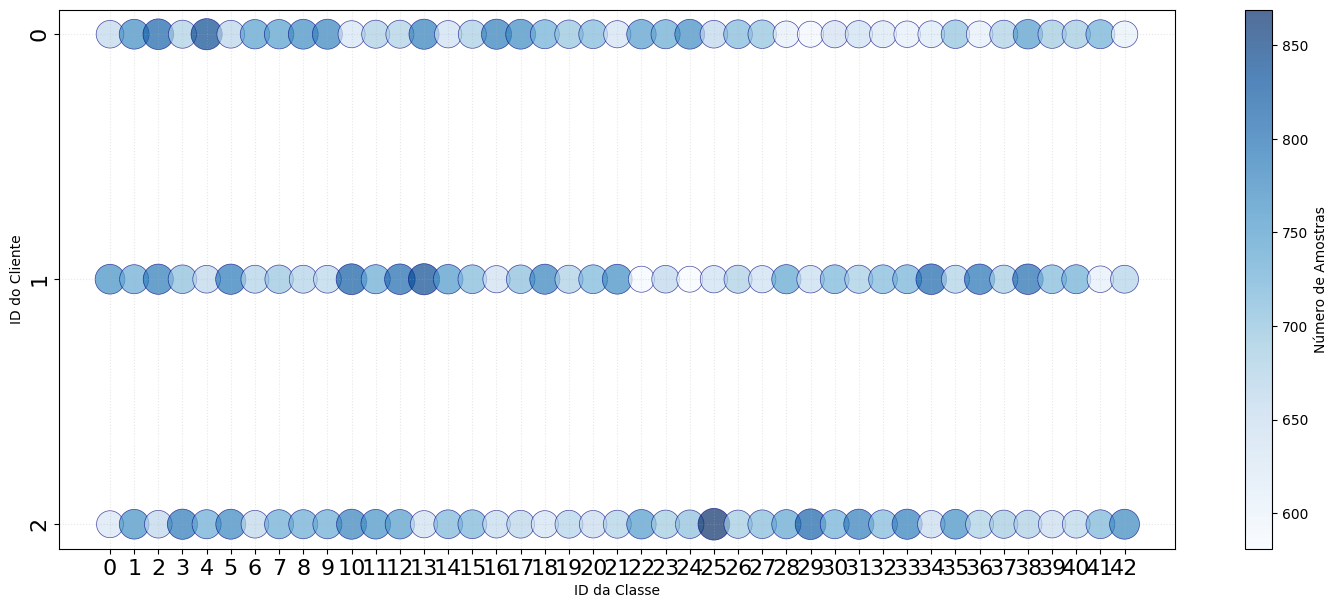

In [5]:
generate_datasets(dataset_name=dataset_name,
                  alpha=100,
                  n_clients=n_clients)

#### Gerando da distribuição com o valor de alfa igual a 5

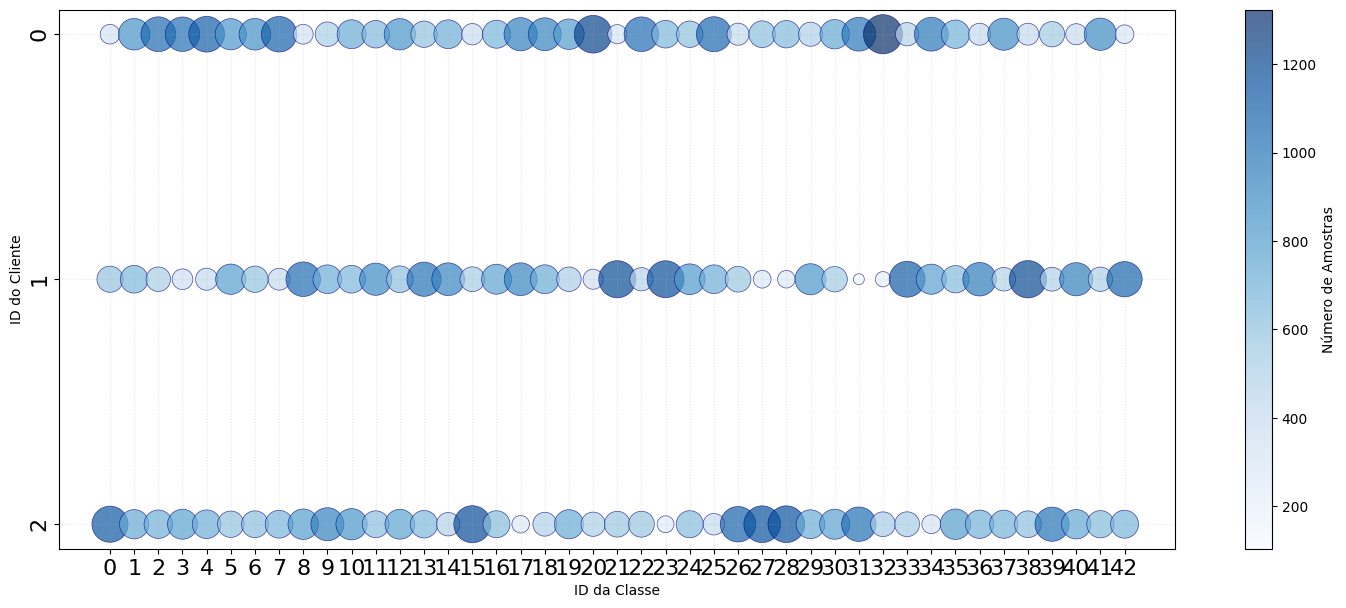

In [6]:
generate_datasets(dataset_name=dataset_name,
                  alpha=5.0,
                  n_clients=n_clients)

#### Gerando da distribuição com o valor de alfa igual a 0.1

In [ ]:
generate_datasets(dataset_name=dataset_name,
                  alpha=0.1,
                  n_clients=n_clients)

## 3 - Simulação da mobilidade de veículos com o SUMO

### Criação dos diretórios

In [ ]:
!source scripts/build/paths.sh

### Geração do modelo de mobilidade

In [ ]:
!source scripts/run/raw/mobility.sh

### Visualização do modelo de mobilidade gerado

### Geração de dados pre-processados para o modelo de comunicação

In [ ]:
!source scripts/run/processed/mobility.sh

### Visualização dos dados de comunicação processados

## 4 - Simulação da comunicação

### Geração dos dados brutos de comunicação a partir do modelo de canal e do padrão de mobilidade fornecidos

In [ ]:
!source scripts/run/raw/communication.sh

### Processamento dos dados brutos de comunicação para utilizá-los no aprendizado federado

In [ ]:
!source scripts/run/processed/communication.sh

### Geração da figura para a visualização

In [ ]:
!source scripts/visualize/throughput.sh

### Visualização dos resultados do canal de comunicação 

In [ ]:
Image(filename=f'figures/communication/speed{speeds[0]}_pt.png')

## 5 - Adaptação do arcabouço Flower para o treinamento federado veicular

### Preparação do Ambiente Federado Veicular

#### Configurando parâmetros do servidor

In [8]:
num_rounds = cfg['simulation']['federated_learning']['server']['rounds']               
server_ip = cfg['simulation']['federated_learning']['server']['ip']
server_port = cfg['simulation']['federated_learning']['server']['port']
num_clients_fit = cfg['simulation']['cars']
num_clients = cfg['simulation']['cars']
aggregation = cfg['simulation']['federated_learning']['server']['strategy']
server_log_path = cfg['simulation']['federated_learning']['server']['log_path']
server_models_path = cfg['simulation']['federated_learning']['server']['model_path']
time_path = cfg['simulation']['federated_learning']['server']['time_path']                
DATASET = cfg['simulation']['data']['name']
alpha = cfg['simulation']['data']['alpha']
MODEL = cfg['simulation']['model']['name']
n_classes = cfg['simulation']['data']['n_classes']
features_shape = int(cfg['simulation']['data']['shape'][-1])
LOG_PATH = 'logs/server/flwr/'

#### Criando diretórios

In [ ]:
os.makedirs(server_log_path, 
            exist_ok=True)

In [7]:
from typing import Dict, List, Optional, Tuple, Union
from flwr.common import Parameters, FitRes

from logging import WARNING


from flwr.common import (
    FitRes,
    Parameters,
    Scalar,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)
from flwr.common.logger import log
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy.aggregate import aggregate_inplace, aggregate

class FedAvg(fl.server.strategy.FedAvg):

    def __init__(self,
                 *args,
                 logger=None,
                 time_path="",
                 **kwargs):
        
        super().__init__(*args,
                         **kwargs)

        self.logger = logger

    def aggregate_fit(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, FitRes]],
        failures: List[Union[Tuple[ClientProxy, FitRes], BaseException]],
    ) -> Tuple[Optional[Parameters], Dict[str, Scalar]]:
        """Aggregate fit results using weighted average."""
        if not results:
            return None, {}
        # Do not aggregate if there are failures and failures are not accepted
        if not self.accept_failures and failures:
            return None, {}

        global_agg_start_time = time.time()

        if self.inplace:
            # Does in-place weighted average of results
            aggregated_ndarrays = aggregate_inplace(results)
        else:
            # Convert results
            weights_results = [
                (parameters_to_ndarrays(fit_res.parameters), fit_res.num_examples)
                for _, fit_res in results
            ]
            aggregated_ndarrays = aggregate(weights_results)

        parameters_aggregated = ndarrays_to_parameters(aggregated_ndarrays)

        # Aggregate custom metrics if aggregation fn was provided
        metrics_aggregated = {}
        if self.fit_metrics_aggregation_fn:
            fit_metrics = [(res.num_examples, res.metrics) for _, res in results]
            metrics_aggregated = self.fit_metrics_aggregation_fn(fit_metrics)
        elif server_round == 1:  # Only log this warning once
            log(WARNING, "No fit_metrics_aggregation_fn provided")

        self.global_agg_time = time.time() - global_agg_start_time

        return parameters_aggregated, metrics_aggregated


In [9]:
logger = create_logger_server(LOG_PATH)

# Initialize model parameters
model, _, _, _, _ = build_model(features_shape=features_shape, 
                                labels_shape=n_classes,
                                model_name=MODEL,
                                lr=0.1)

ndarrays = get_weights(model)

message_length = 800 * 1024 * 1024

parameters = ndarrays_to_parameters(ndarrays)

strategy = FedAvg(min_available_clients=num_clients,
                  min_fit_clients=num_clients_fit,
                  min_evaluate_clients=num_clients,
                  fraction_fit=0.01,
                  fraction_evaluate=0.01,
                  logger=logger,
                  initial_parameters=parameters,
                  time_path=time_path)        

### Execução do treinamento federado